# Iris Species Classification using Machine Learning

## Introduction

This project focuses on classifying Iris flower species using Machine Learning.

The Iris dataset contains measurements of Iris flowers such as sepal length, sepal width, petal length, and petal width.

In this project, we will perform Exploratory Data Analysis (EDA), visualize the dataset, train a Random Forest classification model, and evaluate its performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Dataset Information

Let's examine the structure, size, and data types of the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 5


## Missing Values

We check whether the dataset contains any missing values.

In [6]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## Summary Statistics

The following statistics provide information about the numerical features in the dataset.

In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Visualization 1: Species Distribution

This chart shows the number of samples belonging to each Iris species.

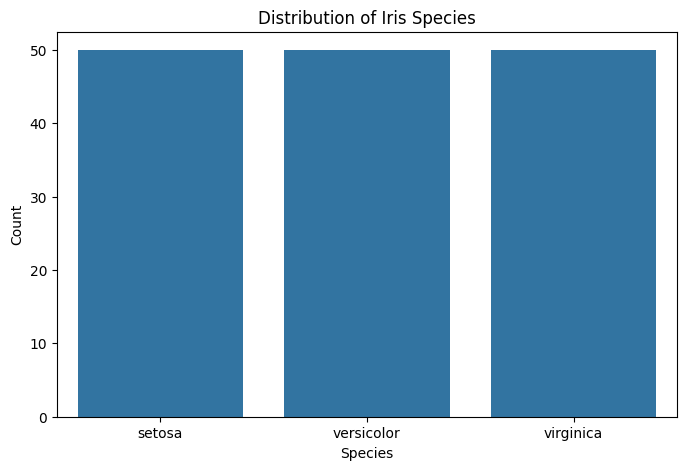

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## Visualization 2: Sepal Length Distribution

This histogram shows the distribution of sepal length values in the dataset.

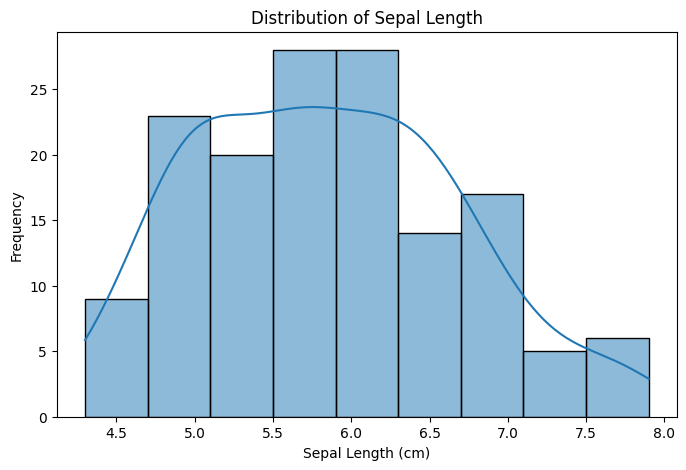

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="sepal length (cm)", kde=True)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")

plt.show()

## Visualization 3: Sepal Width Distribution

This histogram shows the distribution of sepal width values.

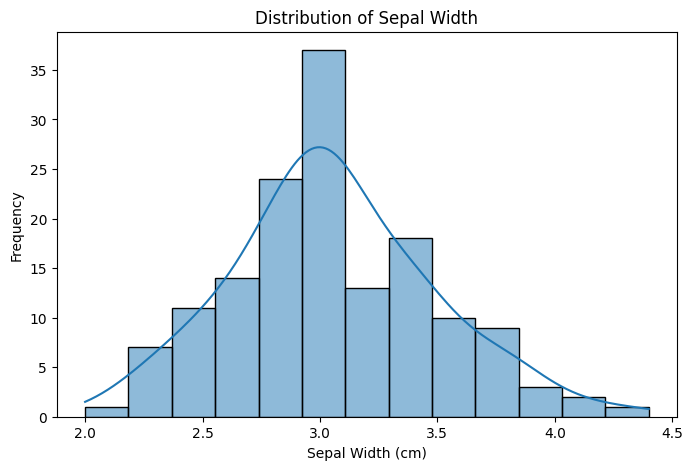

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="sepal width (cm)", kde=True)

plt.title("Distribution of Sepal Width")
plt.xlabel("Sepal Width (cm)")
plt.ylabel("Frequency")

plt.show()

## Visualization 4: Sepal Length vs Sepal Width

This scatter plot shows the relationship between sepal length and sepal width for different Iris species.

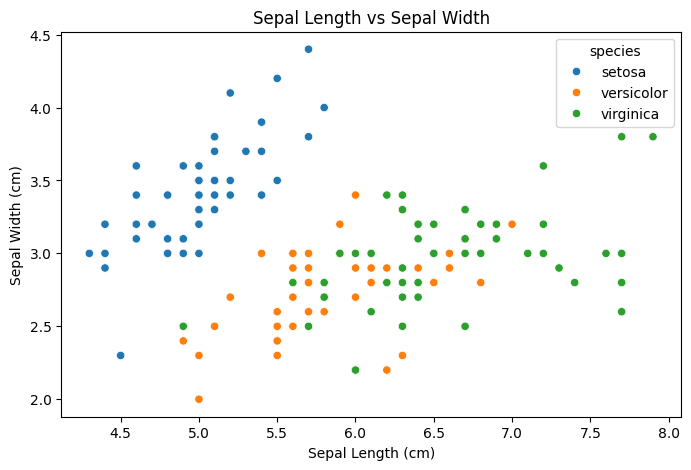

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species"
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.show()

## Visualization 5: Petal Length vs Petal Width

This scatter plot shows the relationship between petal length and petal width for different Iris species.

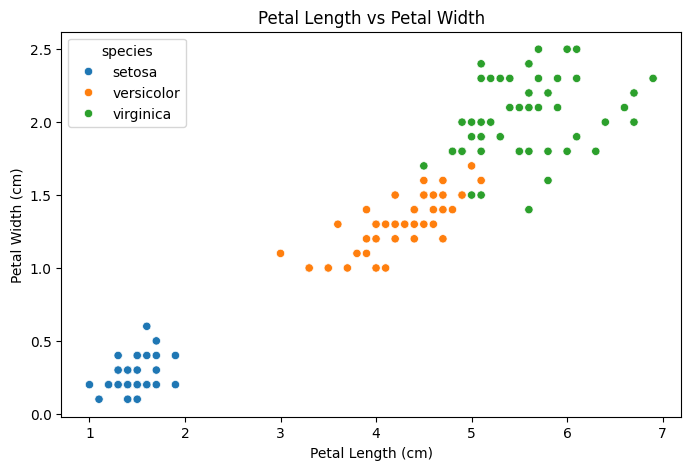

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

## Visualization 6: Feature Correlation

The correlation heatmap shows how strongly the numerical features are related to each other.

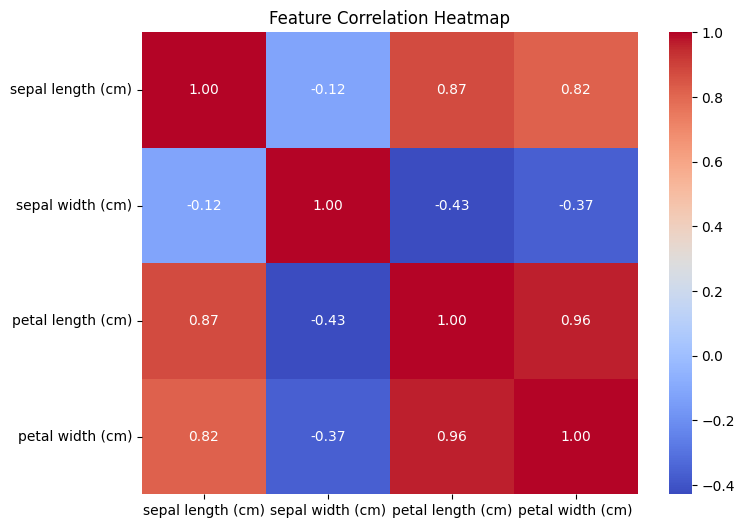

In [13]:
plt.figure(figsize=(8, 6))

correlation = df.drop(columns="species").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Machine Learning Model

We will use the Random Forest Classifier to predict the species of Iris flowers.

The four flower measurements will be used as input features, while the Iris species will be the target variable.

In [14]:
X = df.drop(columns="species")
y = df["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred = model.predict(X_test)

print(y_pred)

['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


## Model Evaluation

### Accuracy Score

Accuracy measures the percentage of test samples that were classified correctly.

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy Score: 0.9
Accuracy Percentage: 90.0 %


### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each Iris species.

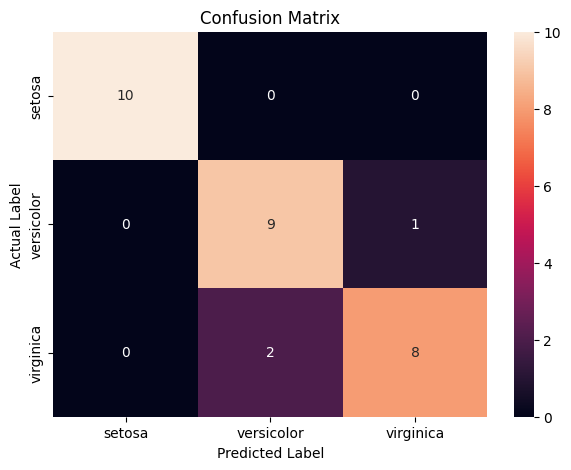

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Classification Report

The classification report provides precision, recall, F1-score, and support for each Iris species.

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## Conclusion

In this project, the Iris dataset was explored using Exploratory Data Analysis and multiple visualizations. The dataset was checked for missing values and summary statistics were analyzed.

A Random Forest Classifier was trained using the Iris flower measurements. The model was evaluated using accuracy score, confusion matrix, and classification report.

The results show that the Random Forest model can effectively classify Iris flowers into their respective species.